# Early Relapse Risk Detection Using Wearable Physiological Signals in AUD using the WESAD Dataset.

In [1]:
# Mount Google Drive so that Colab can access files stored in Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import libraries used for data processing and visualization

import pickle          # used to load the WESAD .pkl dataset files
import numpy as np     # numerical computations
import pandas as pd    # data manipulation
import matplotlib.pyplot as plt   # plotting graphs
import seaborn as sns  # advanced visualizations
import os              # file handling

In [3]:
# Path where the WESAD dataset is stored in Google Drive
dataset_path = "/content/drive/MyDrive/WESAD"

# List all files inside the dataset folder
print(os.listdir(dataset_path))

['S10.pkl', 'S2.pkl', 'S3.pkl', 'S4.pkl', 'S5.pkl', 'S7.pkl', 'S8.pkl', 'S6.pkl', 'S9.pkl', 'S11.pkl', 'S13.pkl', 'S14.pkl', 'S15.pkl', 'S16.pkl', 'S17.pkl']


In [4]:
# Load participant S2 data from the dataset

with open(dataset_path + "/S2.pkl", "rb") as file:
    data = pickle.load(file, encoding="latin1")

In [5]:
# Check the main components stored inside the dataset
print(data.keys())

dict_keys(['signal', 'label', 'subject'])


In [6]:
# Check the data stored inside signals
print(data["signal"].keys())

dict_keys(['chest', 'wrist'])


In [7]:
# Check available wearable sensors
print(data["signal"]["wrist"].keys())

dict_keys(['ACC', 'BVP', 'EDA', 'TEMP'])


In [8]:
labels = data["label"]
print(np.unique(labels))

[0 1 2 3 4 6 7]


In [9]:
# Extract physiological signals from wrist sensors

eda = data["signal"]["wrist"]["EDA"]      # Electrodermal Activity
bvp = data["signal"]["wrist"]["BVP"]      # Blood Volume Pulse
temp = data["signal"]["wrist"]["TEMP"]    # Skin Temperature
labels = data["label"]                    # Experimental labels

In [10]:
# Print the shape (size) of each signal

print("EDA shape:", eda.shape)
print("BVP shape:", bvp.shape)
print("TEMP shape:", temp.shape)
print("Labels shape:", labels.shape)

EDA shape: (24316, 1)
BVP shape: (389056, 1)
TEMP shape: (24316, 1)
Labels shape: (4255300,)


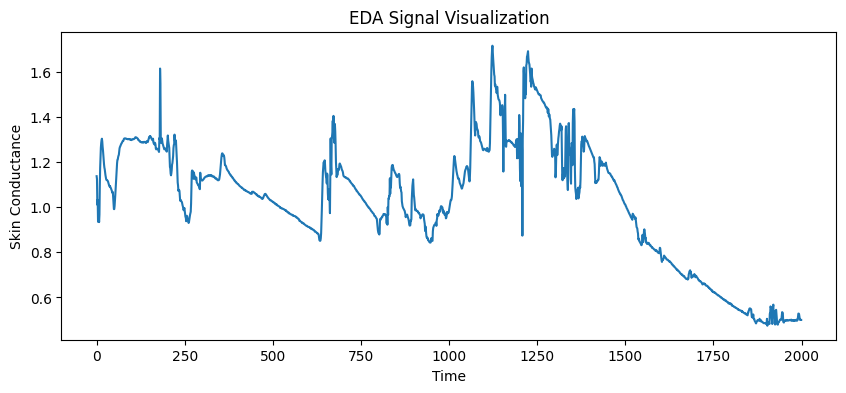

In [11]:
# Plot a portion of the EDA signal to observe physiological patterns

plt.figure(figsize=(10,4))
plt.plot(eda[:2000])
plt.title("EDA Signal Visualization")
plt.xlabel("Time")
plt.ylabel("Skin Conductance")
plt.show()

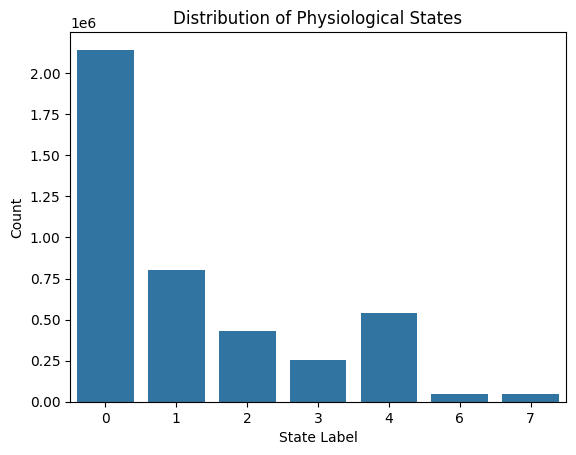

In [12]:
# Visualize how many samples belong to each experimental state

sns.countplot(x=labels)
plt.title("Distribution of Physiological States")
plt.xlabel("State Label")
plt.ylabel("Count")
plt.show()

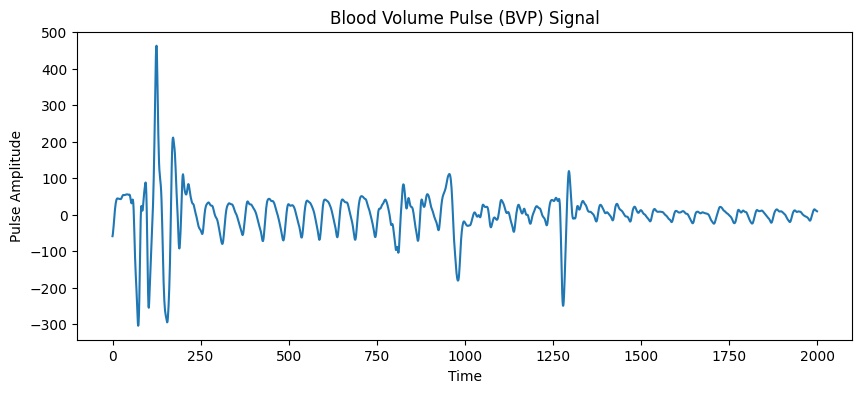

In [13]:
# Visualize Blood Volume Pulse signal

plt.figure(figsize=(10,4))
plt.plot(bvp[:2000])
plt.title("Blood Volume Pulse (BVP) Signal")
plt.xlabel("Time")
plt.ylabel("Pulse Amplitude")
plt.show()

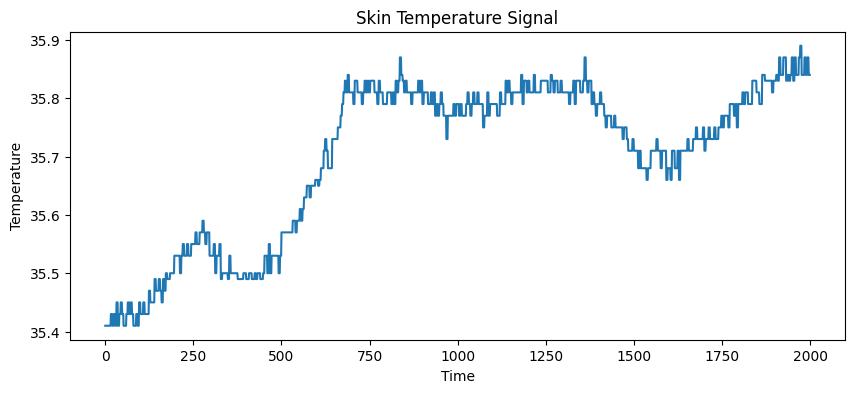

In [14]:
# Visualize skin temperature signal

plt.figure(figsize=(10,4))
plt.plot(temp[:2000])
plt.title("Skin Temperature Signal")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.show()

In [15]:
# Check signal lengths first
print("EDA length:", len(eda))
print("BVP length:", len(bvp))
print("TEMP length:", len(temp))

# Find minimum length
min_len = min(len(eda), len(bvp), len(temp))

# Trim signals to same length
eda_trim = eda[:min_len]
bvp_trim = bvp[:min_len]
temp_trim = temp[:min_len]

# Convert to dataframe
df_signals = pd.DataFrame({
    "EDA": eda_trim.flatten(),
    "BVP": bvp_trim.flatten(),
    "TEMP": temp_trim.flatten()
})

# Display first rows
df_signals.head()

EDA length: 24316
BVP length: 389056
TEMP length: 24316


,EDA,BVP,TEMP
0,1.138257,-59.37,35.41
1,1.125444,-53.42,35.41
2,1.011405,-44.40,35.41
3,1.033188,-33.17,35.41
4,0.935807,-20.79,35.41


# NOTE:
# Physiological signals are recorded at different sampling rates.
# To combine them into a single DataFrame for analysis,
# all signals are trimmed to the same minimum length.

In [16]:
df_signals.describe()

,EDA,BVP,TEMP
count,24316.000000,24316.000000,24316.000000
mean,0.391743,0.031455,34.386945
std,0.329236,82.876912,1.045340
min,0.045113,-638.750000,32.310000
25%,0.169403,-24.810000,33.680000
50%,0.236032,3.660000,34.250000
75%,0.520487,25.302500,35.410000
max,1.717419,597.160000,35.970000


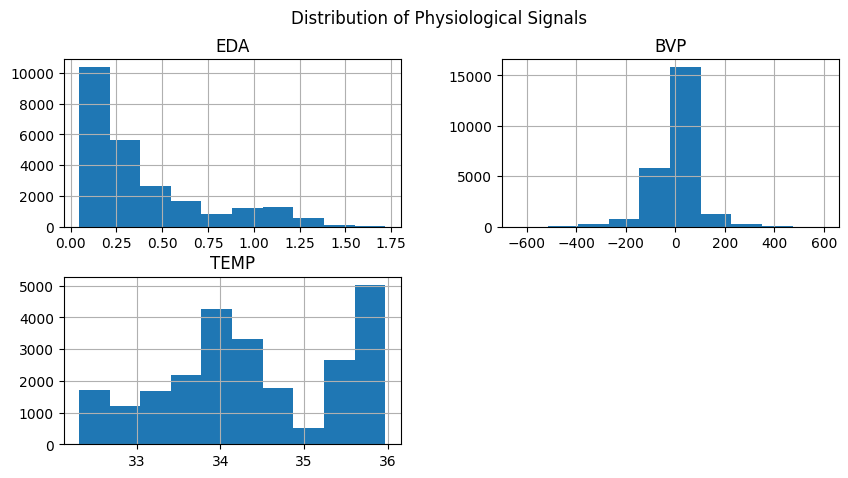

In [17]:
# Plot signal distributions
df_signals.hist(figsize=(10,5))
plt.suptitle("Distribution of Physiological Signals")
plt.show()

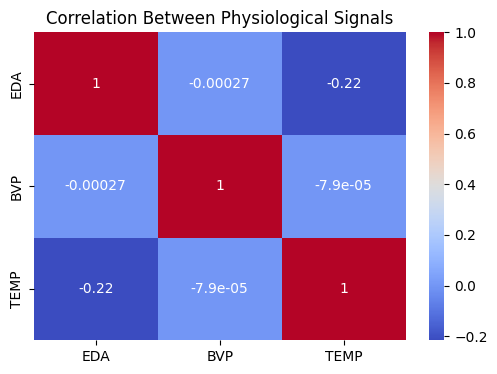

In [18]:
# Correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df_signals.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Physiological Signals")
plt.show()

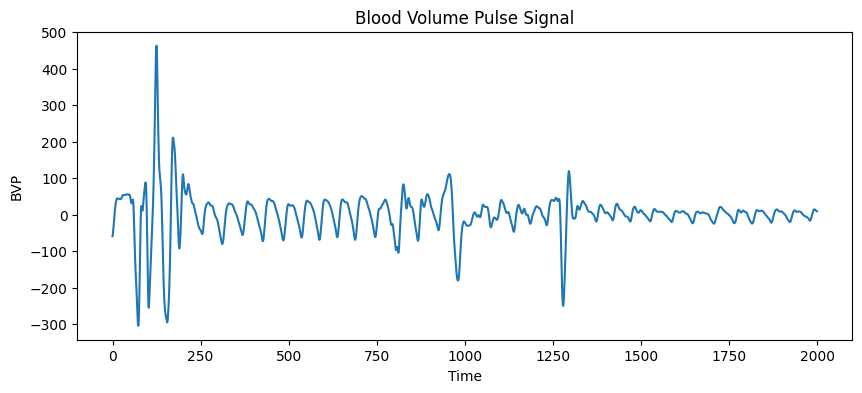

In [19]:
plt.figure(figsize=(10,4))
plt.plot(bvp[:2000])
plt.title("Blood Volume Pulse Signal")
plt.xlabel("Time")
plt.ylabel("BVP")
plt.show()

In [20]:
# List of participants to use
participants = ["S2", "S3", "S4", "S5"]

all_data = []

for p in participants:
    path = dataset_path + "/" + p + ".pkl"

    with open(path, "rb") as file:
        data = pickle.load(file, encoding="latin1")
        all_data.append(data)

print("Participants loaded:", len(all_data))

Participants loaded: 4


In [21]:
# Define window size for segmentation
# Each window will contain 200 signal samples


window_size = 200

samples = []


# Loop through each participant


for participant in all_data:

    # Extract wrist signals
    eda = participant["signal"]["wrist"]["EDA"].flatten()   # Electrodermal Activity
    bvp = participant["signal"]["wrist"]["BVP"].flatten()   # Blood Volume Pulse
    temp = participant["signal"]["wrist"]["TEMP"].flatten() # Skin Temperature

    # Extract activity labels
    labels = participant["label"]


    # IMPORTANT
    # Labels have lower sampling rate than wrist signals
    # We interpolate labels so they match signal length


    labels = np.interp(
        np.linspace(0, len(labels)-1, len(eda)),
        np.arange(len(labels)),
        labels
    ).astype(int)


    # Ensure all signals have the same length


    min_len = min(len(eda), len(bvp), len(temp), len(labels))

    eda = eda[:min_len]
    bvp = bvp[:min_len]
    temp = temp[:min_len]
    labels = labels[:min_len]


    # Sliding window segmentation


    for i in range(0, min_len - window_size, window_size):

        eda_w = eda[i:i+window_size]
        bvp_w = bvp[i:i+window_size]
        temp_w = temp[i:i+window_size]
        label_w = labels[i:i+window_size]


        # Feature extraction
        # Mean and standard deviation of signals


        sample = {

            "EDA_mean": np.mean(eda_w),
            "EDA_std": np.std(eda_w),

            "BVP_mean": np.mean(bvp_w),
            "BVP_std": np.std(bvp_w),

            "TEMP_mean": np.mean(temp_w),
            "TEMP_std": np.std(temp_w),

            # Target label for the window
            # We choose the most frequent label


            "target": int(np.bincount(label_w).argmax())
        }

        samples.append(sample)


# Convert samples into a dataset


df = pd.DataFrame(samples)

print("Dataset size:", df.shape)

df.head()

Dataset size: (503, 7)


,EDA_mean,EDA_std,BVP_mean,BVP_std,TEMP_mean,TEMP_std,target
0,1.239414,0.101734,-1.73325,155.443899,35.4468,0.031714,0
1,1.128671,0.083096,5.52210,39.241065,35.5274,0.027627,0
2,1.015823,0.052278,-4.94585,34.962246,35.5564,0.054581,0
3,1.057460,0.122611,5.52945,34.165432,35.7740,0.056285,0
4,0.987083,0.084150,-4.19135,67.893616,35.8006,0.023699,0


In [22]:
# keep only baseline and stress data

df = df[(df["target"] == 1) | (df["target"] == 2)]

print("Filtered dataset size:", df.shape)

Filtered dataset size: (145, 7)


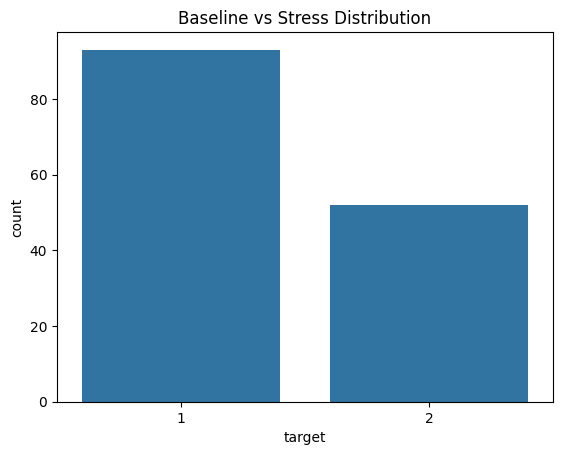

In [23]:
sns.countplot(x=df["target"])
plt.title("Baseline vs Stress Distribution")
plt.show()

In [24]:
# Separate features and labels

X = df.drop("target", axis=1)
y = df["target"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
# X contains physiological features
# y contains the class label (baseline or stress)

Feature shape: (145, 6)
Target shape: (145,)


In [25]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (116, 6)
Testing samples: (29, 6)


# 80% of data is used for training
# 20% is used for testing the model

In [26]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train model
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

# Random Forest is used because it works well with tabular data
# and can handle nonlinear relationships between features

In [27]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

Model Accuracy: 0.9655172413793104
              precision    recall  f1-score   support

           1       1.00      0.95      0.97        20
           2       0.90      1.00      0.95         9

    accuracy                           0.97        29
   macro avg       0.95      0.97      0.96        29
weighted avg       0.97      0.97      0.97        29



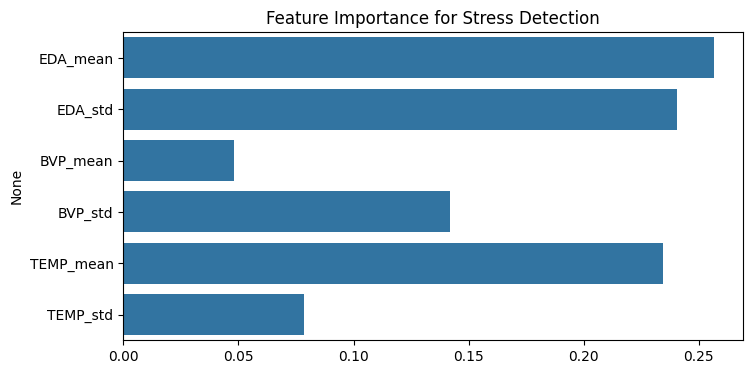

In [28]:
# Feature importance

importances = model.feature_importances_

feature_names = X.columns

plt.figure(figsize=(8,4))
sns.barplot(x=importances, y=feature_names)

plt.title("Feature Importance for Stress Detection")
plt.show()

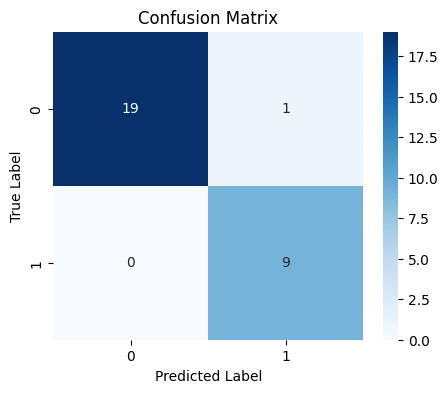

In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

###From the  confusion matrix we can clearly see the detailed evaluation of the model's predictions. It shows how many baseline and stress samples were correctly classified and how many were misclassified. This helps us understand the reliability of the model more than  simple accuracy metrics.

# **# Final Experiment: Using All Participants (S2–S17)**

# After testing the pipeline on a smaller subset, the experiment is extended to all participants to improve model reliability and performance.




In [30]:
participants = [
"S2","S3","S4","S5","S6","S7","S8",
"S9","S10","S11","S13","S14","S15","S16","S17"
]

In [31]:
all_data = []

for p in participants:
    path = dataset_path + "/" + p + ".pkl"

    with open(path, "rb") as file:
        data = pickle.load(file, encoding="latin1")
        all_data.append(data)

print("Participants loaded:", len(all_data))

Participants loaded: 15


In [32]:
samples = []

In [33]:
# Define window size for segmentation
# Each window will contain 200 signal samples


window_size = 200

samples = []


# Loop through each participant


for participant in all_data:

    # Extract wrist signals
    eda = participant["signal"]["wrist"]["EDA"].flatten()   # Electrodermal Activity
    bvp = participant["signal"]["wrist"]["BVP"].flatten()   # Blood Volume Pulse
    temp = participant["signal"]["wrist"]["TEMP"].flatten() # Skin Temperature

    # Extract activity labels
    labels = participant["label"]


    # IMPORTANT
    # Labels have lower sampling rate than wrist signals
    # We interpolate labels so they match signal length


    labels = np.interp(
        np.linspace(0, len(labels)-1, len(eda)),
        np.arange(len(labels)),
        labels
    ).astype(int)


    # Ensure all signals have the same length


    min_len = min(len(eda), len(bvp), len(temp), len(labels))

    eda = eda[:min_len]
    bvp = bvp[:min_len]
    temp = temp[:min_len]
    labels = labels[:min_len]


    # Sliding window segmentation


    for i in range(0, min_len - window_size, window_size):

        eda_w = eda[i:i+window_size]
        bvp_w = bvp[i:i+window_size]
        temp_w = temp[i:i+window_size]
        label_w = labels[i:i+window_size]


        # Feature extraction
        # Mean and standard deviation of signals


        sample = {

            "EDA_mean": np.mean(eda_w),
            "EDA_std": np.std(eda_w),

            "BVP_mean": np.mean(bvp_w),
            "BVP_std": np.std(bvp_w),

            "TEMP_mean": np.mean(temp_w),
            "TEMP_std": np.std(temp_w),

            # Target label for the window
            # We choose the most frequent label


            "target": int(np.bincount(label_w).argmax())
        }

        samples.append(sample)


# Convert samples into a dataset


df = pd.DataFrame(samples)

print("Dataset size:", df.shape)

df.head()

Dataset size: (1729, 7)


,EDA_mean,EDA_std,BVP_mean,BVP_std,TEMP_mean,TEMP_std,target
0,1.239414,0.101734,-1.73325,155.443899,35.4468,0.031714,0
1,1.128671,0.083096,5.52210,39.241065,35.5274,0.027627,0
2,1.015823,0.052278,-4.94585,34.962246,35.5564,0.054581,0
3,1.057460,0.122611,5.52945,34.165432,35.7740,0.056285,0
4,0.987083,0.084150,-4.19135,67.893616,35.8006,0.023699,0


In [34]:
df_all = pd.DataFrame(samples)

print("Dataset size:", df_all.shape)

Dataset size: (1729, 7)


In [35]:
df_all = df_all[(df_all["target"] == 1) | (df_all["target"] == 2)]

print("Filtered dataset size:", df_all.shape)

Filtered dataset size: (551, 7)


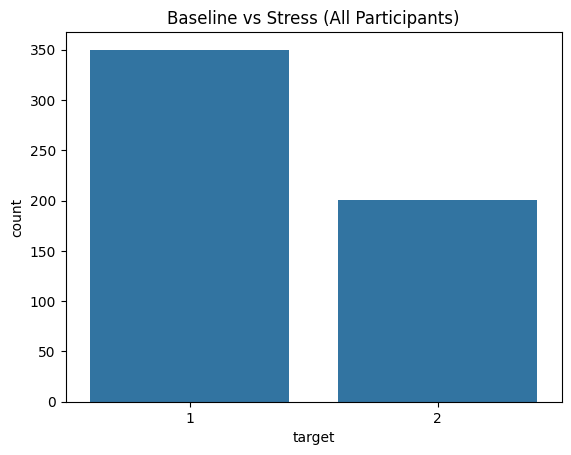

In [36]:
sns.countplot(x=df_all["target"])
plt.title("Baseline vs Stress (All Participants)")
plt.show()

In [37]:
X = df_all.drop("target", axis=1)
y = df_all["target"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [38]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [39]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8738738738738738
              precision    recall  f1-score   support

           1       0.94      0.86      0.90        74
           2       0.77      0.89      0.82        37

    accuracy                           0.87       111
   macro avg       0.85      0.88      0.86       111
weighted avg       0.88      0.87      0.88       111



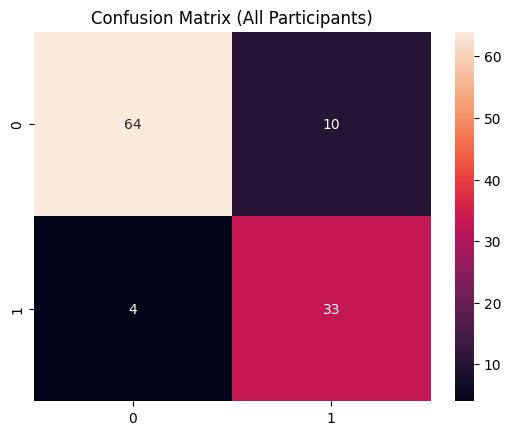

In [40]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix (All Participants)")
plt.show()

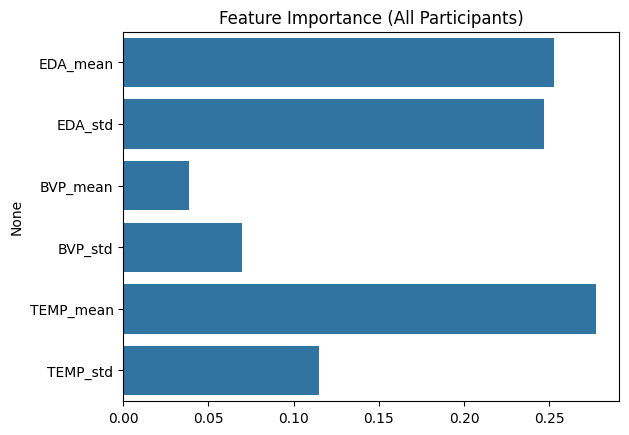

In [41]:
importances = model.feature_importances_

sns.barplot(x=importances, y=X.columns)
plt.title("Feature Importance (All Participants)")
plt.show()

# This shows that EDA and temperature are more important features for detecting stress compared to BVP.